<a href="https://colab.research.google.com/github/umair594/Machine-Learning-Projects/blob/main/Reveal_Categories_Found_in_Data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 7 : Reveal Categories Found in Data using NLP & K-Means Clustering**

**Project Overview**

In this project, we use Natural Language Processing (NLP) and K-Means Clustering to discover hidden categories in textual data.

Although the original project idea focuses on Google Play Store reviews, the uploaded dataset is the Netflix Titles dataset. Therefore, we will replicate the same concept using Netflix movie and TV show descriptions.

**The goal is to:**

Clean and preprocess text data

Convert text into numerical vectors using TF-IDF

Apply K-Means clustering

Discover hidden content categories automatically

Visualize clusters using PCA

Interpret insights from clusters

**This project demonstrates practical applications of:**

Unsupervised Machine Learning

NLP preprocessing

Feature engineering

Text vectorization

Dimensionality reduction

Data visualization

# **Step 1 : Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Warnings
import warnings
warnings.filterwarnings('ignore')

# **Step 2 : Download NLTK Resources**

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# **Step 3 : Load Dataset**

In [ ]:
df = pd.read_csv('netflix_titles.csv')

# **Step 4 : Explore Dataset**

In [ ]:
print(df.head())
print(df.info())
print(df.isnull().sum())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

**Dataset Features**

**Some important columns:**

title

type

director

cast

country

listed_in

description

We will use the description column for NLP clustering.

# **Step 5 : Handle Missing Values**

In [ ]:
# Keep only rows with descriptions
df = df[['title', 'description']]

# Drop missing descriptions
df.dropna(subset=['description'], inplace=True)

print(df.shape)

(8807, 2)


# **Step 6 : Text Preprocessing**

**We will:**

Convert text to lowercase

Remove punctuation

Remove numbers

Remove stopwords

Apply lemmatization

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(words)


# Apply cleaning
df['cleaned_description'] = df['description'].apply(clean_text)

print(df[['description', 'cleaned_description']].head())

                                         description  \
0  As her father nears the end of his life, filmm...   
1  After crossing paths at a party, a Cape Town t...   
2  To protect his family from a powerful drug lor...   
3  Feuds, flirtations and toilet talk go down amo...   
4  In a city of coaching centers known to train I...   

                                 cleaned_description  
0  father nears end life filmmaker kirsten johnso...  
1  crossing path party cape town teen set prove w...  
2  protect family powerful drug lord skilled thie...  
3  feud flirtation toilet talk go among incarcera...  
4  city coaching center known train india finest ...  


# **Step 7 : Convert Text into Numerical Features (TF-IDF)**

In [ ]:
# TF-IDF converts text into numerical vectors based on word importance.

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['cleaned_description'])

print(X.shape)

(8807, 5000)


# **Step 8 : Find Optimal Number of Clusters**

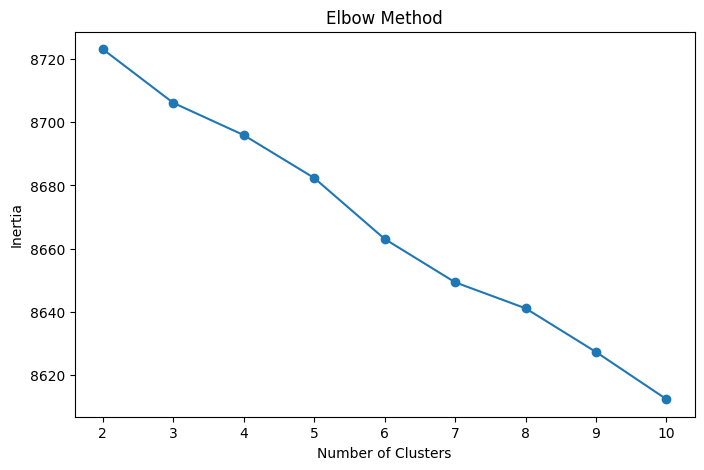

In [ ]:
# We use the Elbow Method.

inertia = []

K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

Choose the cluster value where the curve starts flattening.

**For this project, we will use:**

In [ ]:
optimal_clusters = 5

# **Step 9 : Train K-Means Clustering Model**

In [ ]:
kmeans = KMeans(
    n_clusters=optimal_clusters,
    random_state=42
)

kmeans.fit(X)

# Assign clusters
df['cluster'] = kmeans.labels_

print(df[['title', 'cluster']].head())

                   title  cluster
0   Dick Johnson Is Dead        1
1          Blood & Water        0
2              Ganglands        0
3  Jailbirds New Orleans        4
4           Kota Factory        1


# **Step 10 : Evaluate Clustering Performance**

In [ ]:
# We use the Silhouette Score.

score = silhouette_score(X, df['cluster'])

print('Silhouette Score:', score)

Silhouette Score: 0.002538939357733463


**Interpretation**

Closer to 1 = Better clustering

Around 0 = Overlapping clusters

Negative = Poor clustering

# **Step 11 : Visualize Clusters using PCA**

Since TF-IDF creates thousands of dimensions, we reduce them to 2 dimensions using PCA.

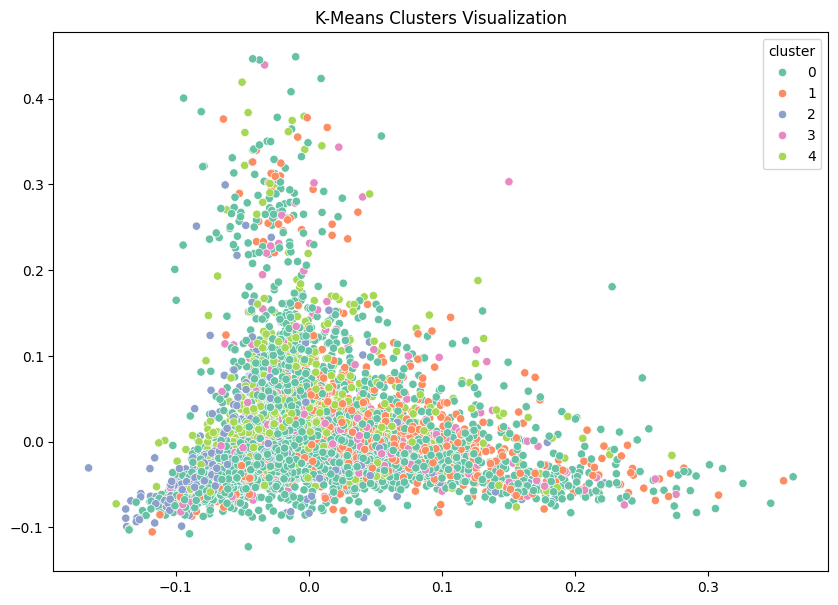

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['cluster'],
    palette='Set2'
)

plt.title('K-Means Clusters Visualization')
plt.show()

# **Step 12 : Discover Cluster Categories**

We identify important keywords from each cluster.

In [ ]:
terms = vectorizer.get_feature_names_out()

for i in range(optimal_clusters):
    print(f'\nCluster {i}')

    center_terms = kmeans.cluster_centers_[i]
    top_terms = center_terms.argsort()[-10:][::-1]

    keywords = [terms[ind] for ind in top_terms]

    print(keywords)


Cluster 0
['family', 'young', 'woman', 'friend', 'man', 'love', 'two', 'series', 'get', 'story']

Cluster 1
['life', 'find', 'woman', 'love', 'young', 'family', 'friend', 'man', 'way', 'series']

Cluster 2
['world', 'world war', 'war', 'around', 'around world', 'war ii', 'ii', 'new', 'life', 'documentary']

Cluster 3
['year', 'save', 'battle', 'must', 'family', 'return', 'young', 'two', 'life', 'fight']

Cluster 4
['new', 'take', 'new york', 'york', 'life', 'friend', 'city', 'young', 'family', 'home']


# **Step 13 : Interpret Clusters**

**Example cluster interpretations:**


**Cluster**	                            **Possible Theme**

0	                                  Crime & Investigation

1                                 	Romance & Relationships

2                                  	Family & Kids

3	                                  Action & Adventure

4	                                  Horror & Mystery

These categories are automatically discovered using NLP and clustering.

# **Step 14 : View Sample Titles from Each Cluster**

In [ ]:
for i in range(optimal_clusters):
    print(f'\n================ Cluster {i} ================')

    sample_titles = df[df['cluster'] == i]['title'].head(10)

    for title in sample_titles:
        print(title)


================ Cluster 0 ================
Blood & Water
Ganglands
Midnight Mass
My Little Pony: A New Generation
Sankofa
The Great British Baking Show
Vendetta: Truth, Lies and The Mafia
Bangkok Breaking
Je Suis Karl
Crime Stories: India Detectives

================ Cluster 1 ================
Dick Johnson Is Dead
Kota Factory
The Starling
Dear White People
Dark Skies
Paranoia
Ankahi Kahaniya
The Father Who Moves Mountains
My Heroes Were Cowboys
Castle and Castle

================ Cluster 2 ================
Europe's Most Dangerous Man: Otto Skorzeny in Spain
Love on the Spectrum
Pokémon Master Journeys: The Series
Mighty Raju
Into the Night
JJ+E
Tobot Galaxy Detectives
Anjaam
Hotel Del Luna
Q-Force

================ Cluster 3 ================
Jaws 2
Dharmakshetra
InuYasha the Movie: Affections Touching Across Time
Naruto Shippûden the Movie: Bonds
Naruto Shippuden: The Movie: The Lost Tower
You vs. Wild: Out Cold
Show Dogs
Poseidon
Tears of the Sun
The Blue Lagoon

================ C

# **Step 15 : Save Final Dataset**

In [ ]:
df.to_csv('netflix_clustered_output.csv', index=False)

**This file contains:**

Original title

Description

Cleaned text

Assigned cluster/category

# **Key Concepts Learned**

**NLP Skills**

Text preprocessing

Stopword removal

Lemmatization

TF-IDF vectorization

**Machine Learning Skills**

Unsupervised learning

K-Means clustering

Elbow method

Silhouette score

PCA dimensionality reduction

**Data Analysis Skills**

Cluster interpretation

Theme discovery

Pattern recognition

Visualization

# **Real-World Applications**

**This type of project is used in:**

Customer feedback analysis

Review categorization

Content recommendation systems

Social media monitoring

Product analytics

Market research

Sentiment grouping

Topic discovery

# **Expected Results**

**After completing this project:**

Netflix content descriptions are automatically grouped into meaningful categories

Similar movies/shows appear in the same cluster

Hidden themes are discovered without labeled data

NLP transforms raw text into machine-readable features

K-Means successfully identifies patterns in textual data

**In this project, we successfully applied NLP and clustering techniques to organize Netflix descriptions into meaningful categories.**

**Using TF-IDF vectorization and K-Means clustering, we transformed unstructured text into actionable insights and automatically discovered hidden themes in the dataset.**

**This project demonstrates the power of unsupervised machine learning for analyzing large-scale text data and extracting valuable business insights.**